In [7]:
from scipy.io import wavfile
from matplotlib import pyplot as plt
samplerate, data = wavfile.read('string_3.wav')



In [2]:
#Sample exploration
samplerate

22050

In [3]:
import numpy as np

In [4]:
#Data exploration
data

array([  61,  114,  103, ..., -124, -149, -151], dtype=int16)

In [5]:
data.shape

(124344,)

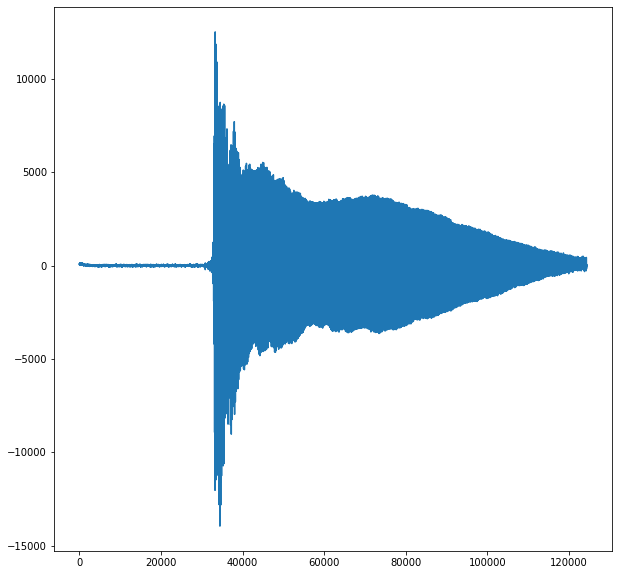

In [8]:
#Plot the string wave
plt.figure(figsize=(10,10))
plt.plot(data)

In [9]:
#Fourier transform libraries
from scipy.fft import fft, ifft,fftfreq

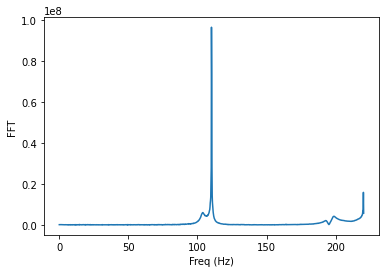

In [12]:
#Prepare to plot fourier transform
N = data.shape[0]#6#int(data.shape[0]/samplerate)
# sample spacing
T = 1.0 / samplerate
# x = np.linspace(0.0, N*T, N, endpoint=False)
# y = np.sin(50.0 * 2.0*np.pi*x) + 0.5*np.sin(80.0 * 2.0*np.pi*x)
yf = fft(data)
xf = fftfreq(N, T)[:N//100]
plt.xlabel('Freq (Hz)')
plt.ylabel('FFT')
plt.plot(xf, np.abs(yf)[:N//100])
plt.show()

In [13]:
#Get frecuencies
xf

array([0.00000000e+00, 1.77330631e-01, 3.54661262e-01, ...,
       2.19889983e+02, 2.20067313e+02, 2.20244644e+02])

In [16]:
#Get highest
def get_highest_freqs(x, y):
    res = []
    for i in range(len(x)):
        if y[i] > 10000000: #This is arbitrary
            res.append(x[i])
            
    return res

In [14]:
len(xf), len(yf)

(1243, 124344)

In [17]:
res = get_highest_freqs(xf, yf)

In [18]:
res

[109.94499131441806, 110.29965257672264]

In [20]:
#Filter the notes
notes = []
for r in res:
    if r < 335 and r > 325:
        notes.append("Got E1")
    if r < 251 and r > 240:
        notes.append("Got B2")
    if r < 201 and r > 190:
        notes.append("Got G3")
    if r < 150 and r > 140:
        notes.append("Got D4")
    if r < 115 and r > 105:
        notes.append("Got E6")
    if r < 87 and r > 78:
        notes.append("Got E6")
        
np.unique(notes).tolist()

['Got E6']

In [27]:
#I have found an interesting library called librosa
import librosa
import librosa.display


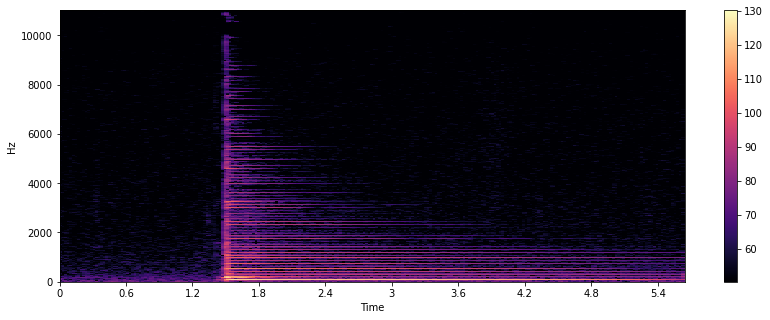

In [32]:
#This needs some revising, it is just the copied code
data=data.astype(np.float32) #Needs float
#==========COPY=========
X = librosa.stft(data)
Xdb = librosa.amplitude_to_db(abs(X))
plt.figure(figsize=(14, 5))
librosa.display.specshow(Xdb, x_axis='time', y_axis='hz')
plt.colorbar()

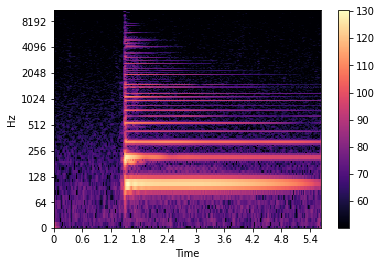

In [33]:
librosa.display.specshow(Xdb, x_axis='time', y_axis='log')
plt.colorbar()

In [34]:
import sklearn
spectral_centroids = librosa.feature.spectral_centroid(data)[0]
spectral_centroids.shape

(243,)

In [35]:
# Normalising the spectral centroid for visualisation
def normalize(x, axis=0):
    return sklearn.preprocessing.minmax_scale(x, axis=axis)

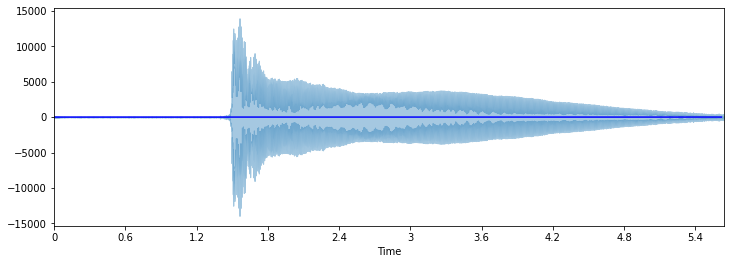

In [42]:
# Computing the time variable for visualization
plt.figure(figsize=(12, 4))
frames = range(len(spectral_centroids))
t = librosa.frames_to_time(frames)
#Plotting the Spectral Centroid along the waveform
librosa.display.waveplot(data, alpha=0.4)
plt.plot(t, normalize(spectral_centroids), color='b')

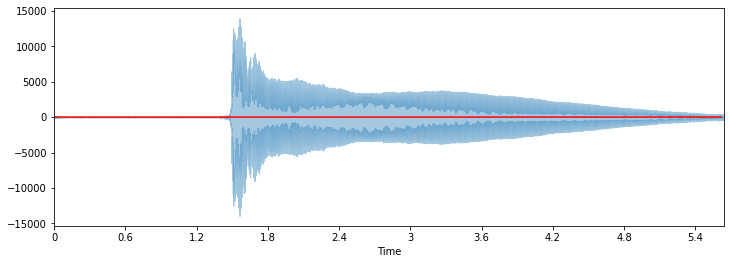

In [45]:
spectral_rolloff = librosa.feature.spectral_rolloff(data+0.01)[0]
plt.figure(figsize=(12, 4))
librosa.display.waveplot(data, alpha=0.4)
plt.plot(t, normalize(spectral_rolloff), color='r')

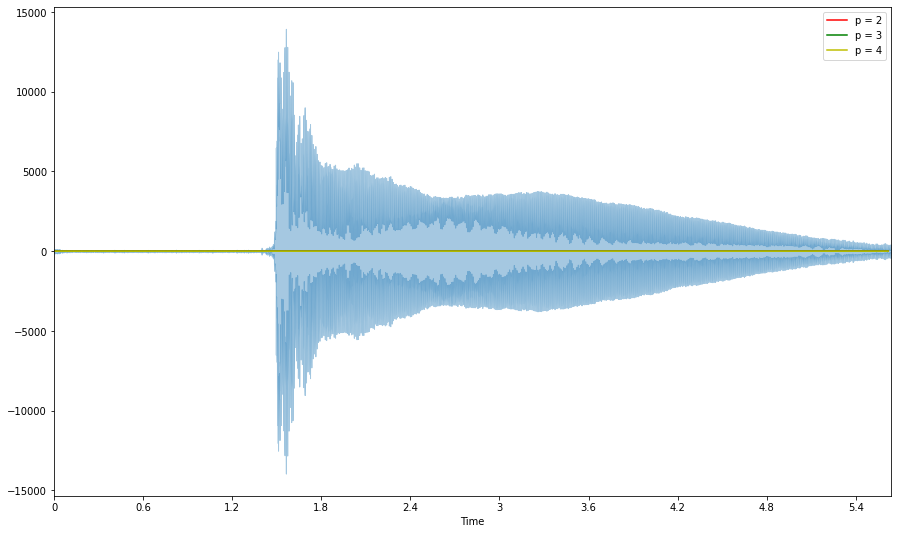

In [46]:
spectral_bandwidth_2 = librosa.feature.spectral_bandwidth(data+0.01)[0]
spectral_bandwidth_3 = librosa.feature.spectral_bandwidth(data+0.01, p=3)[0]
spectral_bandwidth_4 = librosa.feature.spectral_bandwidth(data+0.01, p=4)[0]
plt.figure(figsize=(15, 9))
librosa.display.waveplot(data, alpha=0.4)
plt.plot(t, normalize(spectral_bandwidth_2), color='r')
plt.plot(t, normalize(spectral_bandwidth_3), color='g')
plt.plot(t, normalize(spectral_bandwidth_4), color='y')
plt.legend(('p = 2', 'p = 3', 'p = 4'))

In [47]:
mfccs = librosa.feature.mfcc(data)
print(mfccs.shape)



(20, 243)


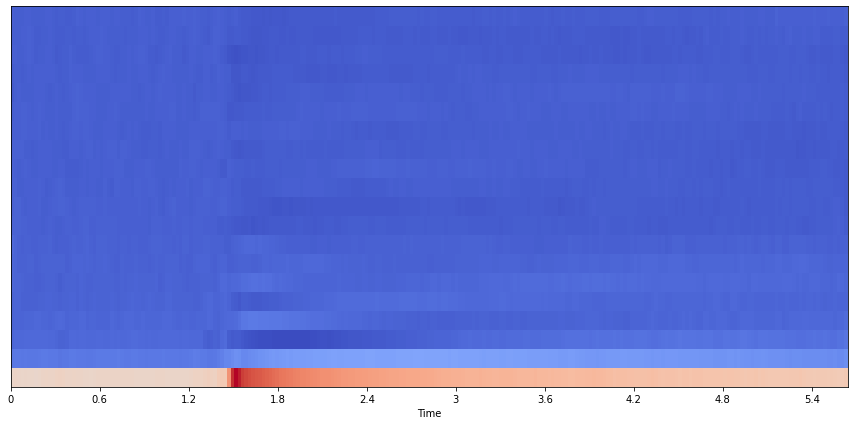

In [49]:
#Displaying  the MFCCs:
plt.figure(figsize=(15, 7))
librosa.display.specshow(mfccs, x_axis='time')

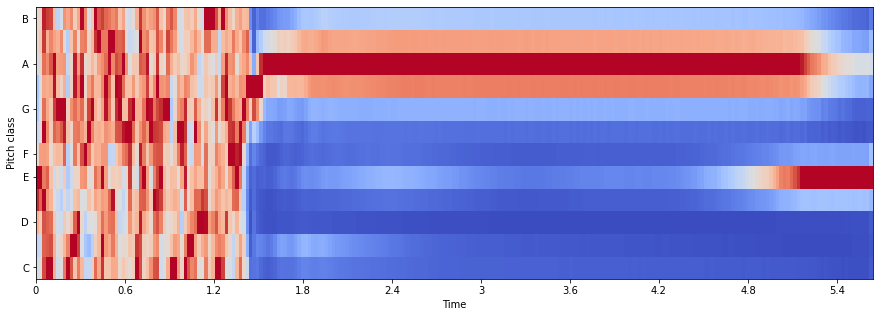

In [50]:
chromagram = librosa.feature.chroma_stft(data)
plt.figure(figsize=(15, 5))
librosa.display.specshow(chromagram, x_axis='time', y_axis='chroma', cmap='coolwarm')